In [1]:
from pathlib import Path
import zipfile

zip_path = "/home/jovyan/notebooks/raw_data/geology/CNS_AUs.zip"

extract_path = Path(zip_path).parent / "CNS_AUs"
extract_path.mkdir(exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extracted to:", extract_path)

Extracted to: /home/jovyan/notebooks/raw_data/geology/CNS_AUs


In [2]:
import os

for root, dirs, files in os.walk(extract_path):
    for f in files:
        if f.endswith(".shp"):
            shp_path = os.path.join(root, f)
            print("Shapefile:", shp_path)

Shapefile: /home/jovyan/notebooks/raw_data/geology/CNS_AUs/CNS_AUs.shp


In [4]:
import geopandas as gpd

gdf_au = gpd.read_file(shp_path)

print("Columns:")
print(gdf_au.columns.tolist())

print("\nPreview:")
display(gdf_au.head())

Columns:
['REGNUM', 'REGNAME', 'PROVCODE', 'PROVNAME', 'TPSCODE', 'TPSNAME', 'ASSESSCODE', 'ASSESSNAME', 'geometry']

Preview:


,REGNUM,REGNAME,PROVCODE,PROVNAME,TPSCODE,TPSNAME,ASSESSCODE,ASSESSNAME,geometry
0,5,North America,5001,Northern Alaska,500107,Arctic Alaska Composite,50010705,Brookian Topset,"POLYGON ((173707.896 2296873.985, 173727.927 2..."
1,5,North America,5001,Northern Alaska,500107,Arctic Alaska Composite,50010706,Brookian Foreset-Bottomset,"POLYGON ((173707.896 2296873.985, 173727.927 2..."
2,5,North America,5001,Northern Alaska,500107,Arctic Alaska Composite,50010707,Beaufortian Strata North,"POLYGON ((173707.896 2296873.985, 173727.927 2..."
3,5,North America,5001,Northern Alaska,500107,Arctic Alaska Composite,50010708,Beaufortian Strata South,"POLYGON ((127613.261 2223813.029, 128099.119 2..."
4,5,North America,5001,Northern Alaska,500107,Arctic Alaska Composite,50010709,Ellesmerian Strata North,"MULTIPOLYGON (((252973.529 2283658.574, 252976..."


In [5]:
# === CLEAN ASSESSMENT UNITS (FINAL) ===

rename_map = {
    "REGNAME": "region",
    "PROVNAME": "province",
    "TPSNAME": "tps_name",
    "ASSESSNAME": "au_name"
}

keep_cols = list(rename_map.keys()) + ["geometry"]

gdf_au = gdf_au[keep_cols].copy()
gdf_au = gdf_au.rename(columns=rename_map)

gdf_au["type"] = "assessment_unit"

In [6]:
gdf_au_3338 = gdf_au.to_crs("EPSG:3338")

<Axes: >

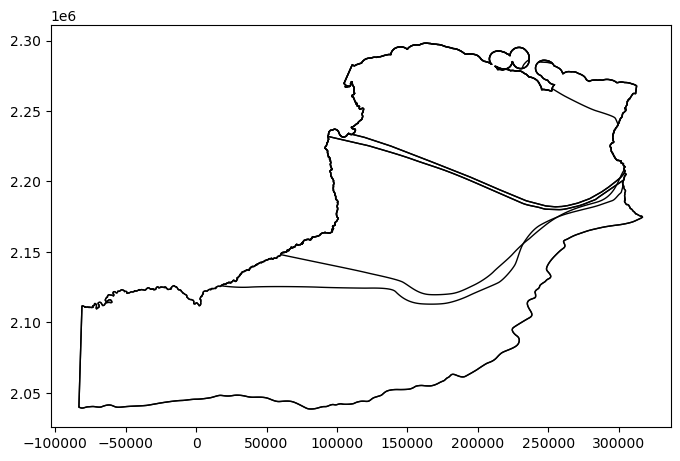

In [7]:
gdf_au_3338.plot(edgecolor="black", facecolor="none", figsize=(8,6))

In [8]:
gdf_au_3338.to_parquet("north_slope_assessment_units.parquet")

In [1]:
from pathlib import Path
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point

# --------------------------------------------------
# CONFIG
# --------------------------------------------------
BASE_DIR = Path("/home/jovyan/notebooks/raw_data/north_slope_depth_grids")
OUTPUT_FILE = Path("/home/jovyan/notebooks/north_slope_structural_surfaces.parquet")
TARGET_CRS = "EPSG:3338"   # same CRS as your cleaned map layers

# --------------------------------------------------
# HELPER: load XYZ file
# --------------------------------------------------
def load_xyz_surface(file_path, skiprows=8):
    rows = []

    with open(file_path, "r") as f:
        lines = f.readlines()[skiprows:]

    for line in lines:
        parts = line.strip().split()
        if len(parts) == 5:
            try:
                x, y, z, lon, lat = map(float, parts)
                rows.append((x, y, z, lon, lat))
            except ValueError:
                continue

    df = pd.DataFrame(rows, columns=["x", "y", "z", "lon", "lat"])
    return df

# --------------------------------------------------
# HELPER: guess layer metadata from filename
# --------------------------------------------------
def classify_layer_name(stem):
    s = stem.lower()

    if "basement" in s:
        return "basement"
    elif "moho" in s:
        return "moho"
    elif "top" in s:
        return stem.lower()
    elif "base" in s:
        return stem.lower()
    else:
        return stem.lower()

def classify_value_type(stem):
    s = stem.lower()
    if "depth" in s or "basement" in s or "moho" in s:
        return "depth"
    return "unknown"

# --------------------------------------------------
# LOAD ALL XYZ SURFACES
# --------------------------------------------------
all_surfaces = []

for fp in sorted(BASE_DIR.glob("*.XYZ")):
    print(f"Loading {fp.name}...")
    df = load_xyz_surface(fp)

    if df.empty:
        print(f"  skipped {fp.name} (no rows)")
        continue

    df["layer_name"] = classify_layer_name(fp.stem)
    df["value_type"] = classify_value_type(fp.stem)
    df["source_file"] = fp.name

    all_surfaces.append(df)

# combine
surface_df = pd.concat(all_surfaces, ignore_index=True)

print("\nCombined rows:", len(surface_df))
print("Layers found:", surface_df["layer_name"].nunique())
print(surface_df["layer_name"].value_counts())

# --------------------------------------------------
# BUILD GEODATAFRAME
# --------------------------------------------------
gdf_surfaces = gpd.GeoDataFrame(
    surface_df,
    geometry=gpd.points_from_xy(surface_df["x"], surface_df["y"]),
    crs=TARGET_CRS
)

# optional: also keep lon/lat geometry copy later if needed
# gdf_surfaces_ll = gpd.GeoDataFrame(
#     surface_df,
#     geometry=gpd.points_from_xy(surface_df["lon"], surface_df["lat"]),
#     crs="EPSG:4326"
# )

# --------------------------------------------------
# CLEAN COLUMN ORDER
# --------------------------------------------------
gdf_surfaces = gdf_surfaces[
    ["layer_name", "value_type", "source_file", "x", "y", "lon", "lat", "z", "geometry"]
].copy()

# --------------------------------------------------
# SAVE
# --------------------------------------------------
gdf_surfaces.to_parquet(OUTPUT_FILE, index=False)

print(f"\nSaved: {OUTPUT_FILE}")
print(gdf_surfaces.head())

Loading NSLCU-Shublik.XYZ...
Loading NSLCU.XYZ...
Loading NSbasement.XYZ...
Loading NSshublik-basement.XYZ...
Loading NSshublik.XYZ...
Loading NStopo-LCU.XYZ...
Loading NStopo-basement.XYZ...
Loading NStopo.XYZ...

Combined rows: 723840
Layers found: 6
layer_name
basement         271440
nslcu-shublik     90480
nslcu             90480
nsshublik         90480
nstopo-lcu        90480
nstopo            90480
Name: count, dtype: int64

Saved: /home/jovyan/notebooks/north_slope_structural_surfaces.parquet
      layer_name value_type        source_file         x          y  \
0  nslcu-shublik    unknown  NSLCU-Shublik.XYZ -630000.0  2000000.0   
1  nslcu-shublik    unknown  NSLCU-Shublik.XYZ -627000.0  2000000.0   
2  nslcu-shublik    unknown  NSLCU-Shublik.XYZ -624000.0  2000000.0   
3  nslcu-shublik    unknown  NSLCU-Shublik.XYZ -621000.0  2000000.0   
4  nslcu-shublik    unknown  NSLCU-Shublik.XYZ -618000.0  2000000.0   

         lon       lat    z                 geometry  
0 -168.67649 

In [2]:
gdf_surfaces[gdf_surfaces["layer_name"] == "basement"]

,layer_name,value_type,source_file,x,y,lon,lat,z,geometry
180960,basement,depth,NSbasement.XYZ,-630000.0,2000000.0,-168.67649,67.32879,-611.0,POINT (-630000 2000000)
180961,basement,depth,NSbasement.XYZ,-627000.0,2000000.0,-168.60884,67.33470,-791.0,POINT (-627000 2000000)
180962,basement,depth,NSbasement.XYZ,-624000.0,2000000.0,-168.54116,67.34059,-1092.0,POINT (-624000 2000000)
180963,basement,depth,NSbasement.XYZ,-621000.0,2000000.0,-168.47344,67.34646,-1391.0,POINT (-621000 2000000)
180964,basement,depth,NSbasement.XYZ,-618000.0,2000000.0,-168.40570,67.35229,-1668.0,POINT (-618000 2000000)
...,...,...,...,...,...,...,...,...,...
633355,basement,depth,NStopo-basement.XYZ,660000.0,2621000.0,-134.50338,72.74522,10003.0,POINT (660000 2621000)
633356,basement,depth,NStopo-basement.XYZ,663000.0,2621000.0,-134.41979,72.73713,10029.0,POINT (663000 2621000)
633357,basement,depth,NStopo-basement.XYZ,666000.0,2621000.0,-134.33627,72.72902,10052.0,POINT (666000 2621000)
633358,basement,depth,NStopo-basement.XYZ,669000.0,2621000.0,-134.25281,72.72087,10074.0,POINT (669000 2621000)


In [3]:
gdf_3d = gpd.read_parquet("/home/jovyan/notebooks/clean_3d_seismic.parquet")
gdf_surfaces = gpd.read_parquet("/home/jovyan/notebooks/north_slope_structural_surfaces.parquet")

surface_in_3d = gpd.sjoin(
    gdf_surfaces,
    gdf_3d[["survey_name", "survey_type", "geometry"]],
    how="left",
    predicate="within"
)

surface_in_3d.head()

,layer_name,value_type,source_file,x,y,lon,lat,z,geometry,index_right,survey_name,survey_type
0,nslcu-shublik,unknown,NSLCU-Shublik.XYZ,-630000.0,2000000.0,-168.67649,67.32879,0.0,POINT (-630000 2000000),NaN,NaN,NaN
1,nslcu-shublik,unknown,NSLCU-Shublik.XYZ,-627000.0,2000000.0,-168.60884,67.33470,0.0,POINT (-627000 2000000),NaN,NaN,NaN
2,nslcu-shublik,unknown,NSLCU-Shublik.XYZ,-624000.0,2000000.0,-168.54116,67.34059,0.0,POINT (-624000 2000000),NaN,NaN,NaN
3,nslcu-shublik,unknown,NSLCU-Shublik.XYZ,-621000.0,2000000.0,-168.47344,67.34646,0.0,POINT (-621000 2000000),NaN,NaN,NaN
4,nslcu-shublik,unknown,NSLCU-Shublik.XYZ,-618000.0,2000000.0,-168.40570,67.35229,0.0,POINT (-618000 2000000),NaN,NaN,NaN


In [4]:
print("SURFACES CRS:", gdf_surfaces.crs)
print("3D CRS:", gdf_3d.crs)

SURFACES CRS: {"$schema": "https://proj.org/schemas/v0.7/projjson.schema.json", "type": "ProjectedCRS", "name": "NAD83 / Alaska Albers", "base_crs": {"name": "NAD83", "datum": {"type": "GeodeticReferenceFrame", "name": "North American Datum 1983", "ellipsoid": {"name": "GRS 1980", "semi_major_axis": 6378137, "inverse_flattening": 298.257222101}}, "coordinate_system": {"subtype": "ellipsoidal", "axis": [{"name": "Geodetic latitude", "abbreviation": "Lat", "direction": "north", "unit": "degree"}, {"name": "Geodetic longitude", "abbreviation": "Lon", "direction": "east", "unit": "degree"}]}, "id": {"authority": "EPSG", "code": 4269}}, "conversion": {"name": "Alaska Albers (meter)", "method": {"name": "Albers Equal Area", "id": {"authority": "EPSG", "code": 9822}}, "parameters": [{"name": "Latitude of false origin", "value": 50, "unit": "degree", "id": {"authority": "EPSG", "code": 8821}}, {"name": "Longitude of false origin", "value": -154, "unit": "degree", "id": {"authority": "EPSG", "c

In [5]:
print(gdf_3d.geom_type.value_counts())
print(gdf_surfaces.geom_type.value_counts())

Polygon         21
MultiPolygon    15
Name: count, dtype: int64
Point    723840
Name: count, dtype: int64


In [6]:
print("SURFACES BOUNDS:", gdf_surfaces.total_bounds)
print("3D BOUNDS:", gdf_3d.total_bounds)

SURFACES BOUNDS: [-630000. 2000000.  672000. 2621000.]
3D BOUNDS: [ -74902.8108 1086763.49    242037.431  2340610.0814]


<Axes: >

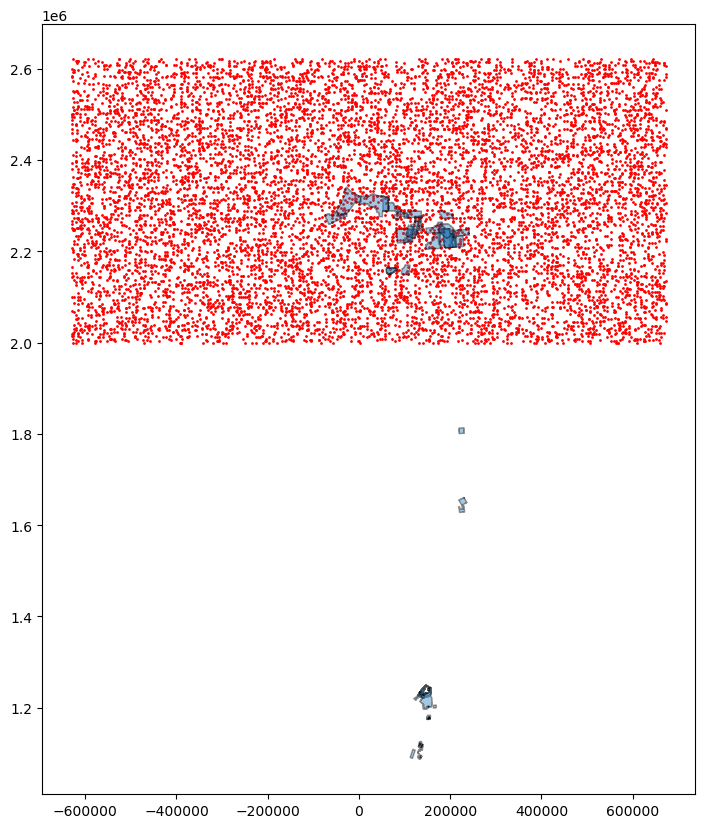

In [7]:
ax = gdf_surfaces.sample(10000).plot(figsize=(10,10), color="red", markersize=1)
gdf_3d.plot(ax=ax, alpha=0.4, edgecolor="black")


In [8]:
gdf_3d_union = gdf_3d.dissolve()[["geometry"]]

surfaces_in_3d_extent = gpd.sjoin(
    gdf_surfaces,
    gdf_3d_union,
    how="inner",
    predicate="intersects"
).drop(columns=["index_right"])

print("Before:", len(gdf_surfaces))
print("After:", len(surfaces_in_3d_extent))

Before: 723840
After: 9840


In [9]:
surface_in_3d = gpd.sjoin(
    surfaces_in_3d_extent,
    gdf_3d[["survey_name", "survey_type", "geometry"]],
    how="left",
    predicate="intersects"
)

surface_in_3d["survey_name"].value_counts()

survey_name
NE NPRA 3D                                                    1528
Aklaq, Smith Bay & Simpson 3D                                 1392
Great Bear 2015 Seismic 3D                                    1144
Great Bear 2016 Seismic 3D                                    1072
Horseshoe 3D                                                   872
Great Bear 2014 Seismic 3D                                     816
Storms 3D                                                      656
Great Bear 2013 Seismic 3D (Dalton)                            640
Puviaq South 3D                                                576
Schrader Bluff 3D                                              552
Big Island / North Island 3D (aka North Slope Winter 2007)     464
Nanuq South 3D                                                 432
Nigliq Fjord 3D                                                432
Kad River 3D                                                   408
North Shore 3D                                    

In [10]:
surface_in_3d.to_parquet(
    "/home/jovyan/notebooks/north_slope_structural_surfaces_3d_ready.parquet",
    index=False
)

In [11]:
gdf_wells = gpd.read_parquet("clean_well_locations.parquet")

wells_with_structure = gpd.sjoin_nearest(
    gdf_wells,
    surface_in_3d[["layer_name", "z", "geometry"]],
    how="left"
)

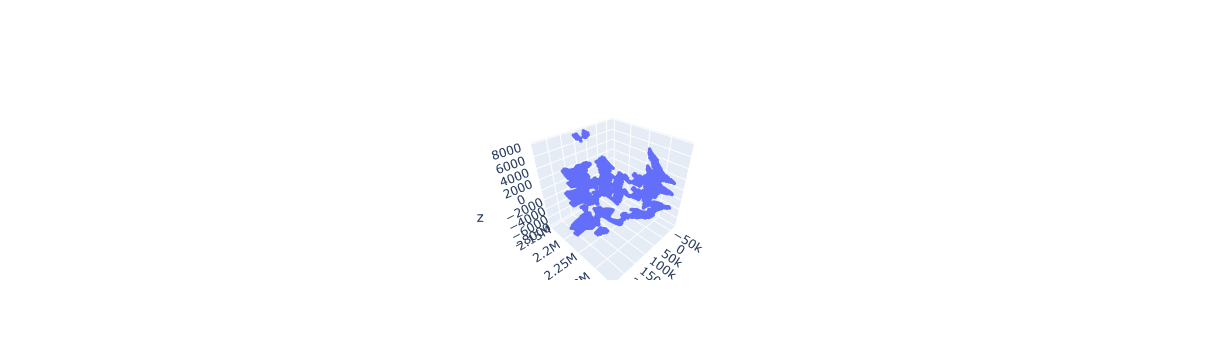

In [12]:
layer = surface_in_3d[surface_in_3d["layer_name"] == "basement"]

import plotly.graph_objects as go

fig = go.Figure(data=[
    go.Scatter3d(
        x=layer["x"],
        y=layer["y"],
        z=layer["z"],
        mode='markers',
        marker=dict(size=2)
    )
])

fig.show()

In [20]:
print(test[["layer_name", "survey_name", "x", "y", "z"]].head(20))
print(test["z"].describe())
print(test["z"].value_counts().head(20))

       layer_name survey_name        x          y       z
221640   basement  NE NPRA 3D  45000.0  2279000.0 -3506.0
221641   basement  NE NPRA 3D  48000.0  2279000.0 -3395.0
221642   basement  NE NPRA 3D  51000.0  2279000.0 -3373.0
222075   basement  NE NPRA 3D  45000.0  2282000.0 -3398.0
222076   basement  NE NPRA 3D  48000.0  2282000.0 -3313.0
222077   basement  NE NPRA 3D  51000.0  2282000.0 -3264.0
222510   basement  NE NPRA 3D  45000.0  2285000.0 -3281.0
222511   basement  NE NPRA 3D  48000.0  2285000.0 -3248.0
222512   basement  NE NPRA 3D  51000.0  2285000.0 -3215.0
222943   basement  NE NPRA 3D  39000.0  2288000.0 -3295.0
222944   basement  NE NPRA 3D  42000.0  2288000.0 -3225.0
222945   basement  NE NPRA 3D  45000.0  2288000.0 -3190.0
222946   basement  NE NPRA 3D  48000.0  2288000.0 -3174.0
222947   basement  NE NPRA 3D  51000.0  2288000.0 -3182.0
223378   basement  NE NPRA 3D  39000.0  2291000.0 -3265.0
223379   basement  NE NPRA 3D  42000.0  2291000.0 -3191.0
223380   basem

In [21]:
print("Unique surveys:", test["survey_name"].nunique())
print(test["survey_name"].unique())
print("Unique layers:", test["layer_name"].nunique())
print(test["layer_name"].unique())

Unique surveys: 1
<ArrowStringArray>
['NE NPRA 3D']
Length: 1, dtype: str
Unique layers: 1
<ArrowStringArray>
['basement']
Length: 1, dtype: str


In [22]:
test = surface_in_3d[
    (surface_in_3d["survey_name"] == "NE NPRA 3D") &
    (surface_in_3d["layer_name"] == "basement") &
    (surface_in_3d["z"].notna()) &
    (surface_in_3d["z"] != 0)
].copy()

print(len(test))
print(test["z"].describe())

573
count     573.000000
mean      308.272251
std      2751.616168
min     -3698.000000
25%     -3190.000000
50%       894.000000
75%      3193.000000
max      3704.000000
Name: z, dtype: float64


In [23]:
import plotly.graph_objects as go

fig = go.Figure(
    data=[
        go.Scatter3d(
            x=test["x_local"],
            y=test["y_local"],
            z=test["z"],
            mode="markers",
            marker=dict(size=3)
        )
    ]
)

fig.update_layout(
    title="Basement surface points",
    scene=dict(
        xaxis_title="X local",
        yaxis_title="Y local",
        zaxis_title="Z",
        aspectmode="data"
    )
)

fig.show()

KeyError: 'x_local'

<Axes: >

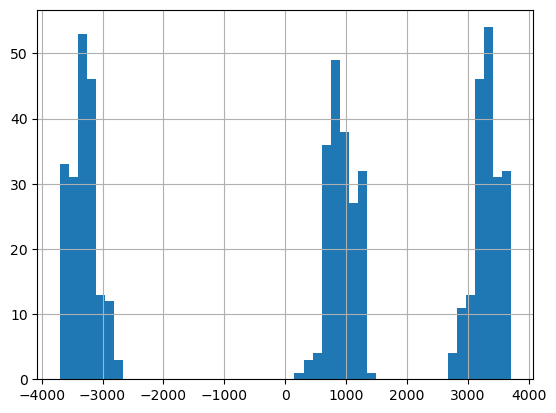

In [24]:
test["z"].hist(bins=50)

In [25]:
neg = test[test["z"] < 0]
pos = test[test["z"] > 0]

print("Negative count:", len(neg))
print("Positive count:", len(pos))

Negative count: 191
Positive count: 382


In [26]:
test = test[test["z"] < 0].copy()

In [27]:
test["x_local"] = test["x"] - test["x"].mean()
test["y_local"] = test["y"] - test["y"].mean()

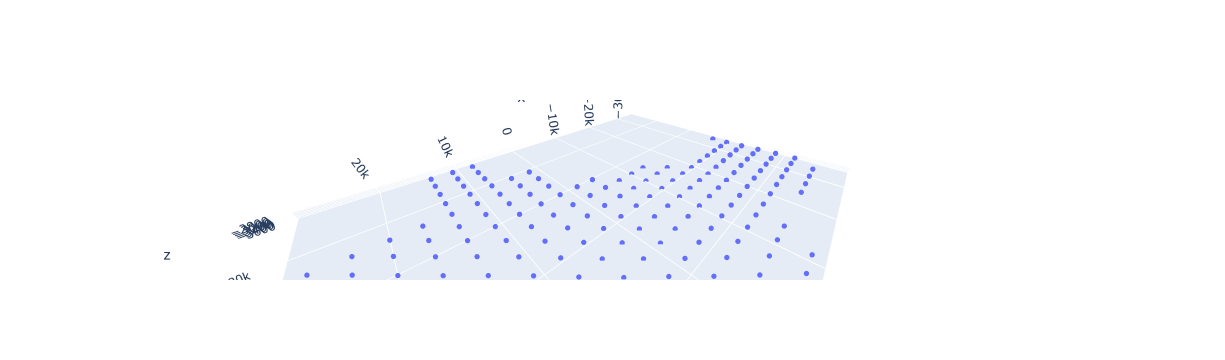

In [28]:
fig = go.Figure(
    data=[
        go.Scatter3d(
            x=test["x_local"],
            y=test["y_local"],
            z=test["z"],
            mode="markers",
            marker=dict(size=3)
        )
    ]
)

fig.update_layout(scene=dict(aspectmode="data"))
fig.show()

In [29]:
test["x_local"] = test["x"] - test["x"].mean()
test["y_local"] = test["y"] - test["y"].mean()

In [31]:
test_neg = surface_in_3d[
    (surface_in_3d["survey_name"] == "NE NPRA 3D") &
    (surface_in_3d["layer_name"] == "basement") &
    (surface_in_3d["z"] < 0)
].copy()

test_neg["x_local"] = test_neg["x"] - test_neg["x"].mean()
test_neg["y_local"] = test_neg["y"] - test_neg["y"].mean()

print(len(test_neg))
print(test_neg["z"].describe())
print(test_neg["source_file"].value_counts())

191
count     191.000000
mean    -3312.706806
std       220.256902
min     -3698.000000
25%     -3459.000000
50%     -3304.000000
75%     -3190.500000
max     -2737.000000
Name: z, dtype: float64
source_file
NSbasement.XYZ    191
Name: count, dtype: int64


In [32]:
test_neg["source_file"].value_counts()

source_file
NSbasement.XYZ    191
Name: count, dtype: int64

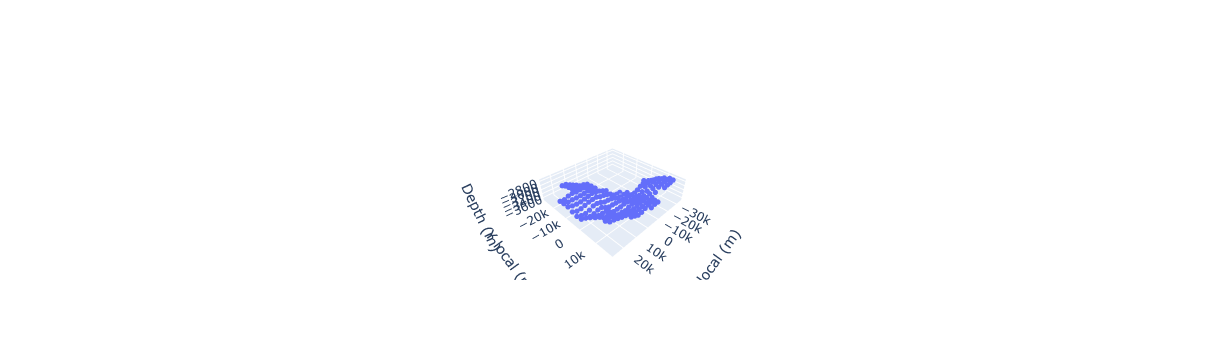

In [33]:
import plotly.graph_objects as go

fig = go.Figure(
    data=[
        go.Scatter3d(
            x=test_neg["x_local"],
            y=test_neg["y_local"],
            z=test_neg["z"],
            mode="markers",
            marker=dict(size=3)
        )
    ]
)

fig.update_layout(
    scene=dict(
        xaxis_title="X local (m)",
        yaxis_title="Y local (m)",
        zaxis_title="Depth (m)",
        aspectmode="manual",
        aspectratio=dict(x=1, y=1, z=0.25)
    )
)

fig.show()

In [34]:
grid = test_neg.pivot_table(
    index="y_local",
    columns="x_local",
    values="z",
    aggfunc="mean"
).sort_index().sort_index(axis=1)

grid.shape

(16, 21)

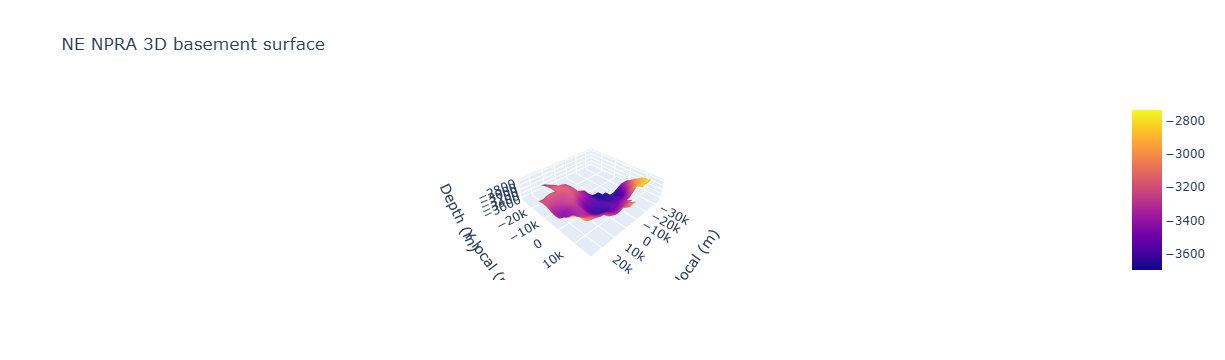

In [35]:
import numpy as np
import plotly.graph_objects as go

X = grid.columns.values
Y = grid.index.values
Z = grid.values

fig = go.Figure(
    data=[
        go.Surface(
            x=X,
            y=Y,
            z=Z
        )
    ]
)

fig.update_layout(
    title="NE NPRA 3D basement surface",
    scene=dict(
        xaxis_title="X local (m)",
        yaxis_title="Y local (m)",
        zaxis_title="Depth (m)",
        aspectmode="manual",
        aspectratio=dict(x=1, y=1, z=0.25)
    )
)

fig.show()